# 09  -  Model Improvements

**Goal:** Improve F1 and MAE over the notebook-06 baseline (F1 ‰ˆ 0.26, MAE ‰ˆ 1.37).

**Baseline:** 22 features (19 technical + 3 GDELT sentiment), default XGBoost params
(`n_estimators=200, max_depth=6, learning_rate=0.1`), class-weighted `sample_weight`.

**Improvements (all genuinely new  -  cross-referenced against nb04nb08):**

| # | Technique | Why new |
|---|-----------|--------|
| 1 | Purged Group Time-Series CV | nb07 used standard TimeSeriesSplit (leaks with 63-day labels) |
| 2 | Recency-weighted samples | Never tried; recent market behavior may matter more |
| 3 | Label boundary noise removal | Never tried; samples near thresholds are noisy |
| 4 | Optuna with purged CV | nb07 Optuna failed because CV was unreliable |
| 5 | Blended ordinal-softmax loss | nb07 tried **pure** ordinal (tanked F1 to 0.15); blended is different |

**NOT repeated (failed in prior notebooks):**
sector dummies, VIX regime, market-relative features, sentiment lags/interactions,
treasury yields, calibration, pure ordinal objective.

In [1]:
import os
import re
import json
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import optuna
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"XGBoost {xgb.__version__}, Optuna {optuna.__version__}")

XGBoost 3.2.0, Optuna 4.8.0


In [2]:
# ============================================================
# Constants
# ============================================================
SIGNAL_LABELS = ["Strong Sell", "Sell", "Hold", "Buy", "Strong Buy"]
THRESHOLDS_3M = (-10, -3, 3, 12)
HORIZON_DAYS = 63
SPLIT_DATE = pd.Timestamp("2025-09-01")

CACHE_DIR = os.path.join(".", "data")
OHLCV_CACHE = os.path.join(CACHE_DIR, "sp500_ohlcv_5y.parquet")
GDELT_CACHE = os.path.join(CACHE_DIR, "gdelt_sentiment_5y.parquet")
PROCESSED_CACHE = os.path.join(CACHE_DIR, "df_3m_with_sentiment.parquet")

TECH_FEATURES = [
    "Price_SMA50_Ratio", "Price_SMA200_Ratio", "Price_EMA20_Ratio",
    "MACD_Norm", "MACD_Signal_Norm", "MACD_Hist_Norm",
    "RSI", "Stoch_K", "Stoch_D", "ROC",
    "BB_Position", "BB_Width", "ATR_Pct",
    "OBV_Norm", "Vol_SMA_Ratio",
    "Dist_52w_High", "Dist_52w_Low", "Return_1m", "Return_3m",
]
SENTIMENT_FEATURES = ["sentiment_avg_20d", "sentiment_volume_20d", "sentiment_momentum"]
ALL_FEATURES = TECH_FEATURES + SENTIMENT_FEATURES

print(f"Features: {len(TECH_FEATURES)} technical + {len(SENTIMENT_FEATURES)} sentiment = {len(ALL_FEATURES)} total")

Features: 19 technical + 3 sentiment = 22 total


In [3]:
# ============================================================
# Utility functions (same as nb06 production code)
# ============================================================

def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute all 19 technical indicator features from OHLCV data."""
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    sma_50 = df["Close"].rolling(50).mean()
    sma_200 = df["Close"].rolling(200).mean()
    ema_20 = df["Close"].ewm(span=20, adjust=False).mean()
    df["Price_SMA50_Ratio"] = df["Close"] / sma_50
    df["Price_SMA200_Ratio"] = df["Close"] / sma_200
    df["Price_EMA20_Ratio"] = df["Close"] / ema_20

    ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = df["Close"].ewm(span=26, adjust=False).mean()
    macd_raw = ema_12 - ema_26
    macd_sig = macd_raw.ewm(span=9, adjust=False).mean()
    df["MACD_Norm"] = macd_raw / df["Close"] * 100
    df["MACD_Signal_Norm"] = macd_sig / df["Close"] * 100
    df["MACD_Hist_Norm"] = df["MACD_Norm"] - df["MACD_Signal_Norm"]

    delta = df["Close"].diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    df["RSI"] = 100 - (100 / (1 + avg_gain / avg_loss))

    low_14 = df["Low"].rolling(14).min()
    high_14 = df["High"].rolling(14).max()
    df["Stoch_K"] = 100 * (df["Close"] - low_14) / (high_14 - low_14)
    df["Stoch_D"] = df["Stoch_K"].rolling(3).mean()
    df["ROC"] = df["Close"].pct_change(21) * 100

    bb_sma = df["Close"].rolling(20).mean()
    bb_std = df["Close"].rolling(20).std()
    bb_upper = bb_sma + 2 * bb_std
    bb_lower = bb_sma - 2 * bb_std
    df["BB_Position"] = (df["Close"] - bb_lower) / (bb_upper - bb_lower)
    df["BB_Width"] = (bb_upper - bb_lower) / bb_sma

    tr = pd.concat([
        df["High"] - df["Low"],
        (df["High"] - df["Close"].shift(1)).abs(),
        (df["Low"] - df["Close"].shift(1)).abs(),
    ], axis=1).max(axis=1)
    df["ATR_Pct"] = tr.rolling(14).mean() / df["Close"] * 100

    obv = (np.sign(df["Close"].diff()) * df["Volume"]).cumsum()
    df["OBV_Norm"] = obv.diff(21) / df["Volume"].rolling(21).mean()
    df["Vol_SMA_Ratio"] = df["Volume"] / df["Volume"].rolling(20).mean()

    df["Dist_52w_High"] = (df["Close"] - df["High"].rolling(252).max()) / df["High"].rolling(252).max() * 100
    df["Dist_52w_Low"] = (df["Close"] - df["Low"].rolling(252).min()) / df["Low"].rolling(252).min() * 100
    df["Return_1m"] = df["Close"].pct_change(21) * 100
    df["Return_3m"] = df["Close"].pct_change(63) * 100
    return df


def compute_future_returns(close, horizon_days):
    return (close.shift(-horizon_days) / close - 1) * 100


def assign_signal(returns, thresholds):
    ss, s, b, sb = thresholds
    conditions = [
        returns < ss, (returns >= ss) & (returns < s),
        (returns >= s) & (returns < b), (returns >= b) & (returns < sb),
        returns >= sb,
    ]
    # Use empty string as default (np.nan breaks np.select with string choices in numpy>=2)
    result = pd.Series(
        np.select(conditions, SIGNAL_LABELS, default=""),
        index=returns.index,
    )
    result = result.replace("", np.nan)
    return result


def eval_model(y_true, y_pred, label="Model"):
    f1 = f1_score(y_true, y_pred, average="weighted")
    acc = accuracy_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{label}: F1={f1:.4f}  Acc={acc:.4f}  MAE={mae:.4f}")
    return {"f1": f1, "acc": acc, "mae": mae}


def bootstrap_ci(y_true, y_pred, n=1000, seed=42):
    rng = np.random.default_rng(seed)
    n_samples = len(y_true)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, n_samples, n_samples)
        scores.append(f1_score(y_true[idx], y_pred[idx], average="weighted"))
    return np.percentile(scores, [2.5, 97.5])


print("Utility functions loaded.")

Utility functions loaded.


## 1. Data Loading & Processing

Load from cached parquets, compute features + labels + sentiment.
Caches the fully-processed dataset to `df_3m_with_sentiment.parquet` for fast re-runs.

In [4]:
if os.path.exists(PROCESSED_CACHE):
    print(f"Loading processed cache from {PROCESSED_CACHE}...")
    df_3m = pd.read_parquet(PROCESSED_CACHE)
    df_3m.index = pd.to_datetime(df_3m.index)
    print(f"Loaded {len(df_3m):,} rows, {df_3m['Ticker'].nunique()} tickers")
else:
    #  Load OHLCV 
    print(f"Loading OHLCV from {OHLCV_CACHE}...")
    ohlcv_all = pd.read_parquet(OHLCV_CACHE)
    all_data = {}
    for ticker in ohlcv_all["Ticker"].unique():
        df = ohlcv_all[ohlcv_all["Ticker"] == ticker].drop(columns=["Ticker"])
        df.index = pd.to_datetime(df.index)
        all_data[ticker] = df
    print(f"Loaded {len(all_data)} tickers")

    #  Compute features 
    print("Computing technical features...")
    processed = {}
    for ticker, df in all_data.items():
        try:
            processed[ticker] = compute_features(df)
        except Exception:
            pass
    print(f"Processed {len(processed)} tickers")

    #  Build labeled dataset (also store future returns for boundary filtering) 
    print("Computing labels...")
    datasets = []
    for ticker, df in processed.items():
        future_ret = compute_future_returns(df["Close"], HORIZON_DAYS)
        signals = assign_signal(future_ret, THRESHOLDS_3M)
        subset = df[TECH_FEATURES].copy()
        subset["Signal"] = signals
        subset["Ticker"] = ticker
        subset["future_return"] = future_ret  # keep for boundary filtering
        subset = subset.dropna(subset=TECH_FEATURES + ["Signal"])
        if len(subset) > 0:
            datasets.append(subset)
    df_3m = pd.concat(datasets).sort_index()
    print(f"Dataset: {len(df_3m):,} rows, {df_3m['Ticker'].nunique()} tickers")

    #  Sentiment features 
    print(f"\nLoading GDELT from {GDELT_CACHE}...")
    gdelt_df = pd.read_parquet(GDELT_CACHE)
    gdelt_df["article_date"] = pd.to_datetime(gdelt_df["article_date"], format="%Y%m%d")
    gdelt_df["sentiment"] = np.clip(gdelt_df["tone"] / 10, -1, 1)
    print(f"Loaded {len(gdelt_df):,} GDELT records")

    # Wikipedia S&P 500 table for ticker <-> company name mapping
    import requests, lxml
    resp = requests.get(
        "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
        headers={"User-Agent": "StockPredictor/1.0 (academic thesis)"},
        timeout=15,
    )
    sp500_table = pd.read_html(resp.text)[0]

    def clean_company_name(name):
        name = name.lower().strip().replace(",", " ").replace(".", " ")
        name = re.sub(r"\s+", " ", name).strip()
        name = re.sub(r"^the ", "", name)
        name = re.sub(r"\s*&\s*co\s*$", "", name)
        name = re.sub(
            r"\s+(inc|corp|co|ltd|llc|plc|lp|nv|sa|corporation|incorporated|"
            r"company|companies|holdings|group|enterprises?|international)\s*$",
            "", name,
        )
        return name.strip()

    # Build company -> ticker mapping
    company_to_tickers = {}
    for _, row in sp500_table.iterrows():
        ticker = row["Symbol"]
        if ticker not in processed:
            continue
        cleaned = clean_company_name(row["Security"])
        company_to_tickers.setdefault(cleaned, []).append(ticker)

    # Map GDELT orgs to tickers
    mapping_rows = []
    for company, ticker_list in company_to_tickers.items():
        for ticker in ticker_list:
            mapping_rows.append({"matched_org": company, "ticker": ticker})
    mapping_df = pd.DataFrame(mapping_rows)
    scored_df = gdelt_df.merge(mapping_df, on="matched_org", how="inner")
    scored_df = scored_df[["ticker", "article_date", "sentiment"]].rename(columns={"article_date": "date"})
    print(f"Matched {scored_df['ticker'].nunique()} tickers in GDELT")

    # Compute rolling sentiment features per ticker
    print("Computing rolling sentiment features...")
    all_feats = []
    matched_tickers = scored_df["ticker"].unique()
    for i, ticker in enumerate(matched_tickers, 1):
        if ticker not in processed:
            continue
        ticker_news = scored_df[scored_df["ticker"] == ticker]
        daily = ticker_news.groupby("date").agg(
            daily_sentiment=("sentiment", "mean"),
            daily_count=("sentiment", "count"),
        )
        trading_dates = processed[ticker].index
        daily_aligned = daily.reindex(trading_dates)
        daily_aligned["daily_sentiment"] = daily_aligned["daily_sentiment"].ffill()
        daily_aligned["daily_count"] = daily_aligned["daily_count"].fillna(0)

        sent_avg_20 = daily_aligned["daily_sentiment"].rolling(20, min_periods=5).mean()
        sent_avg_60 = daily_aligned["daily_sentiment"].rolling(60, min_periods=10).mean()
        sent_vol_20 = daily_aligned["daily_count"].rolling(20, min_periods=1).sum()

        feat_df = pd.DataFrame({
            "ticker": ticker,
            "date": trading_dates,
            "sentiment_avg_20d": sent_avg_20.values,
            "sentiment_volume_20d": sent_vol_20.values,
            "sentiment_momentum": (sent_avg_20 - sent_avg_60).values,
        })
        all_feats.append(feat_df)
        if i % 100 == 0:
            print(f"  [{i}/{len(matched_tickers)}] tickers processed")

    sentiment_features = pd.concat(all_feats, ignore_index=True)
    print(f"Sentiment features computed for {sentiment_features['ticker'].nunique()} tickers")

    # Merge sentiment into df_3m (preserve date index)
    df_3m["date"] = df_3m.index
    df_3m = df_3m.merge(
        sentiment_features,
        left_on=["Ticker", "date"],
        right_on=["ticker", "date"],
        how="left",
    ).drop(columns=["ticker"])
    df_3m = df_3m.set_index("date")
    df_3m.index = pd.to_datetime(df_3m.index)

    coverage = df_3m["sentiment_avg_20d"].notna().mean() * 100
    print(f"\nSentiment coverage: {coverage:.1f}%")

    # Cache processed dataset
    df_3m.to_parquet(PROCESSED_CACHE)
    print(f"Saved processed cache to {PROCESSED_CACHE}")

print(f"\nFinal dataset: {len(df_3m):,} rows, {df_3m['Ticker'].nunique()} tickers")
print(f"Date range: {df_3m.index.min().date()} to {df_3m.index.max().date()}")
print(f"\nClass distribution:")
print(df_3m["Signal"].value_counts().sort_index())

Loading OHLCV from .\data\sp500_ohlcv_5y.parquet...
Loaded 499 tickers
Computing technical features...
Processed 499 tickers
Computing labels...
Dataset: 467,631 rows, 499 tickers

Loading GDELT from .\data\gdelt_sentiment_5y.parquet...
Loaded 66,466,075 GDELT records
Matched 425 tickers in GDELT
Computing rolling sentiment features...
  [100/425] tickers processed
  [200/425] tickers processed
  [300/425] tickers processed
  [400/425] tickers processed
Sentiment features computed for 425 tickers

Sentiment coverage: 83.9%
Saved processed cache to .\data\df_3m_with_sentiment.parquet

Final dataset: 467,631 rows, 499 tickers
Date range: 2022-03-23 to 2025-12-19

Class distribution:
Signal
Buy            112164
Hold            82560
Sell            77464
Strong Buy     118172
Strong Sell     77271
Name: count, dtype: int64


## 2. Baseline Reproduction

Reproduce the nb06 production model exactly: 22 features, default params, class-weighted sample_weight.

In [5]:
#  Train/test split 
le = LabelEncoder()
le.fit(SIGNAL_LABELS)
n_classes = len(SIGNAL_LABELS)

train = df_3m[df_3m.index < SPLIT_DATE]
test = df_3m[df_3m.index >= SPLIT_DATE]

y_train = le.transform(train["Signal"])
y_test = le.transform(test["Signal"])

X_train = train[ALL_FEATURES]
X_test = test[ALL_FEATURES]

# Class weights (same as nb06)
class_counts = Counter(y_train)
total = len(y_train)
class_weights_dict = {cls: total / (n_classes * count) for cls, count in class_counts.items()}
sample_weights = np.array([class_weights_dict[y] for y in y_train])

print(f"Split date: {SPLIT_DATE.date()}")
print(f"Train: {len(train):,} samples ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test:  {len(test):,} samples ({test.index.min().date()} to {test.index.max().date()})")
print(f"\nClass weights: {', '.join(f'{SIGNAL_LABELS[k]}={v:.2f}' for k, v in sorted(class_weights_dict.items()))}")

#  Baseline model 
print(f"\n{'='*50}")
print("Baseline  -  22 features, default params, class weights")
print(f"{'='*50}")

baseline_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    objective="multi:softprob", num_class=n_classes,
    eval_metric="mlogloss", random_state=42, n_jobs=-1,
)
baseline_model.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_baseline = baseline_model.predict(X_test)
baseline_metrics = eval_model(y_test, y_pred_baseline, "Baseline")
ci_baseline = bootstrap_ci(y_test, y_pred_baseline)
print(f"95% CI: [{ci_baseline[0]:.4f}, {ci_baseline[1]:.4f}]")
print(f"\n{classification_report(y_test, y_pred_baseline, target_names=SIGNAL_LABELS, zero_division=0)}")

# Store all results for final comparison
results = {"baseline": {**baseline_metrics, "desc": "nb06 reproduction (22 feat, default params)"}}

Split date: 2025-09-01
Train: 428,713 samples (2022-03-23 to 2025-08-29)
Test:  38,918 samples (2025-09-02 to 2025-12-19)

Class weights: Strong Sell=0.83, Sell=1.13, Hold=1.20, Buy=0.80, Strong Buy=1.22

Baseline  -  22 features, default params, class weights
Baseline: F1=0.2611  Acc=0.2609  MAE=1.3682
95% CI: [0.2568, 0.2655]

              precision    recall  f1-score   support

 Strong Sell       0.28      0.22      0.24      8415
        Sell       0.24      0.24      0.24      6391
        Hold       0.19      0.19      0.19      6087
         Buy       0.33      0.32      0.33     11254
  Strong Buy       0.23      0.30      0.26      6771

    accuracy                           0.26     38918
   macro avg       0.25      0.25      0.25     38918
weighted avg       0.27      0.26      0.26     38918



## 3. Improvement 1  -  Purged Group Time-Series CV

**Problem:** The standard `TimeSeriesSplit` used in nb07's Optuna has label leakage.
Each sample's label depends on future returns over the next 63 trading days.
A training sample near the fold boundary has a label computed from data
*inside* the test fold  -  the model sees the answer during training.

**Fix:** Purge training samples whose 63-day label window overlaps the test fold.
Add an embargo gap after each test fold to prevent feature leakage from lookback indicators.

This doesn't directly improve the model  -  it makes **cross-validation reliable**,
which means Optuna can actually find good hyperparameters.

In [12]:
class PurgedTimeSeriesSplit:
    """Time-series CV with purging and embargo for overlapping labels.

    For financial ML where labels depend on future returns over `horizon_days`,
    this removes training samples whose label window overlaps the test fold
    and adds an embargo gap to prevent feature leakage.

    Reference: Marcos Lopez de Prado, 'Advances in Financial ML' (2018), Ch. 7.
    """

    def __init__(self, n_splits=5, horizon_days=63, embargo_days=5):
        self.n_splits = n_splits
        self.horizon_days = horizon_days
        self.embargo_days = embargo_days

    def split(self, X, y=None, groups=None):
        """Generate purged train/test indices.

        Parameters
        ----------
        X : array-like
        groups : array-like of dates  -  used to determine temporal ordering
                 and to purge by date (not by row index).
        """
        if groups is None:
            raise ValueError("groups (dates) must be provided")

        dates = pd.to_datetime(groups)
        unique_dates = np.sort(dates.unique())
        n_dates = len(unique_dates)

        fold_size = n_dates // (self.n_splits + 1)

        for i in range(self.n_splits):
            test_start_idx = fold_size * (i + 1)
            test_end_idx = min(test_start_idx + fold_size, n_dates)
            if i == self.n_splits - 1:
                test_end_idx = n_dates

            test_dates = set(unique_dates[test_start_idx:test_end_idx])
            test_start_date = unique_dates[test_start_idx]

            # Purge: remove training dates within horizon_days before test start
            purge_cutoff_idx = max(0, test_start_idx - self.horizon_days)
            train_dates = set(unique_dates[:purge_cutoff_idx])

            # Embargo: also exclude embargo_days after test end
            embargo_end_idx = min(test_end_idx + self.embargo_days, n_dates)
            # Include post-embargo data in training (expanding window with gaps)
            if embargo_end_idx < n_dates:
                train_dates |= set(unique_dates[embargo_end_idx:])

            # Map dates to row indices
            train_idx = np.where(dates.isin(train_dates))[0]
            test_idx = np.where(dates.isin(test_dates))[0]

            if len(train_idx) > 0 and len(test_idx) > 0:
                yield train_idx, test_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


#  Demo: compare purged vs standard CV 
print("Comparing Purged CV vs Standard TimeSeriesSplit")
print("=" * 50)

train_dates = pd.to_datetime(train.index)

std_cv = TimeSeriesSplit(n_splits=3)
purged_cv = PurgedTimeSeriesSplit(n_splits=3, horizon_days=HORIZON_DAYS, embargo_days=5)

print("\nStandard TimeSeriesSplit (LEAKY):")
for fold, (tr_idx, te_idx) in enumerate(std_cv.split(X_train)):
    tr_dates = train_dates[tr_idx]
    te_dates = train_dates[te_idx]
    gap = (te_dates.min() - tr_dates.max()).days
    print(f"  Fold {fold+1}: train={len(tr_idx):,} ({tr_dates.max().date()})  "
          f"test={len(te_idx):,} ({te_dates.min().date()})  "
          f"gap={gap}d  LEAKY (labels overlap {HORIZON_DAYS}d forward)")

print(f"\nPurged TimeSeriesSplit (purge={HORIZON_DAYS}d, embargo=5d):")
for fold, (tr_idx, te_idx) in enumerate(purged_cv.split(X_train, groups=train_dates)):
    tr_dates_fold = train_dates[tr_idx]
    te_dates_fold = train_dates[te_idx]
    # Find the gap between last training date and first test date
    tr_before_test = tr_dates_fold[tr_dates_fold < te_dates_fold.min()]
    if len(tr_before_test) > 0:
        gap = (te_dates_fold.min() - tr_before_test.max()).days
    else:
        gap = -1
    print(f"  Fold {fold+1}: train={len(tr_idx):,}  test={len(te_idx):,}  "
          f"purge gap={gap}d  (> {HORIZON_DAYS}d label horizon œ)")

Task was destroyed but it is pending!
task: <Task pending name='Task-195' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-196' coro=<Kernel.shell_main() running at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\Matei\AppData\Local\Programs\Python\Python312\Lib\collections\__init__.py:449: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  result = tuple_new(cls, iterable)
Task was destroyed but it is pending!
task: <Task pending name='Task-196' coro=<Kernel.shell_main() running at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


Comparing Purged CV vs Standard TimeSeriesSplit

Standard TimeSeriesSplit (LEAKY):
  Fold 1: train=107,179 (2023-02-01)  test=107,178 (2023-02-01)  gap=0d  LEAKY (labels overlap 63d forward)
  Fold 2: train=214,357 (2023-12-11)  test=107,178 (2023-12-11)  gap=0d  LEAKY (labels overlap 63d forward)
  Fold 3: train=321,535 (2024-10-21)  test=107,178 (2024-10-21)  gap=0d  LEAKY (labels overlap 63d forward)

Purged TimeSeriesSplit (purge=63d, embargo=5d):
  Fold 1: train=288,400  test=106,640  purge gap=96d  (> 63d label horizon œ)
  Fold 2: train=287,998  test=106,972  purge gap=91d  (> 63d label horizon œ)
  Fold 3: train=288,548  test=108,782  purge gap=91d  (> 63d label horizon œ)


## 4. Improvement 2  -  Recency-Weighted Samples

**Idea:** Market regimes shift. A sample from 2021 is less relevant to predicting
2025+ than a sample from 2024. Apply exponential decay weighting so the model
prioritizes recent behavior.

**Combined with class weights** (multiply recency weight Ã -  class weight).

In [18]:
def recency_weights(dates, half_life_days=365):
    """Exponential decay weights: most recent date = 1.0, older dates decay."""
    dates = pd.to_datetime(dates)
    max_date = dates.max()
    td = max_date - dates
    if isinstance(td, pd.TimedeltaIndex):
        days_ago = td.days.values.astype(float)
    else:
        days_ago = td.dt.days.values.astype(float)
    decay = np.exp(-np.log(2) * days_ago / half_life_days)
    return decay

print("Testing recency weighting (half-life = 365 days)")
print("=" * 50)
rec_weights = recency_weights(train.index, half_life_days=365)
combined_weights = sample_weights * rec_weights
years = pd.to_datetime(train.index).year
for year in sorted(years.unique()):
    mask = years == year
    print(f"  {year}: mean recency weight = {rec_weights[mask].mean():.3f}, "
          f"samples = {mask.sum():,}")

recency_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    objective="multi:softprob", num_class=n_classes,
    eval_metric="mlogloss", random_state=42, n_jobs=-1,
)
recency_model.fit(X_train, y_train, sample_weight=combined_weights)
y_pred_recency = recency_model.predict(X_test)
recency_metrics = eval_model(y_test, y_pred_recency, "Recency-weighted (365d)")
ci_recency = bootstrap_ci(y_test, y_pred_recency)
print(f"95% CI: [{ci_recency[0]:.4f}, {ci_recency[1]:.4f}]")

delta_f1 = recency_metrics["f1"] - baseline_metrics["f1"]
delta_mae = recency_metrics["mae"] - baseline_metrics["mae"]
print(f"\nDelta vs baseline:  F1 {delta_f1:+.4f}  MAE {delta_mae:+.4f}")
results["recency_365d"] = {**recency_metrics, "desc": "+ recency weighting (half-life 365d)"}

# Also test 730-day half-life (gentler decay)
print("\n" + "=" * 50)
rec_weights_730 = recency_weights(train.index, half_life_days=730)
combined_730 = sample_weights * rec_weights_730
recency_model_730 = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    objective="multi:softprob", num_class=n_classes,
    eval_metric="mlogloss", random_state=42, n_jobs=-1,
)
recency_model_730.fit(X_train, y_train, sample_weight=combined_730)
y_pred_recency_730 = recency_model_730.predict(X_test)
recency_730_metrics = eval_model(y_test, y_pred_recency_730, "Recency-weighted (730d)")
delta_f1_730 = recency_730_metrics["f1"] - baseline_metrics["f1"]
print(f"Delta vs baseline:  F1 {delta_f1_730:+.4f}  MAE {recency_730_metrics['mae'] - baseline_metrics['mae']:+.4f}")
results["recency_730d"] = {**recency_730_metrics, "desc": "+ recency weighting (half-life 730d)"}

Testing recency weighting (half-life = 365 days)
  2022: mean recency weight = 0.122, samples = 96,906
  2023: mean recency weight = 0.228, samples = 123,999
  2024: mean recency weight = 0.457, samples = 125,473
  2025: mean recency weight = 0.806, samples = 82,335
Recency-weighted (365d): F1=0.2596  Acc=0.2592  MAE=1.3634
95% CI: [0.2549, 0.2638]

Delta vs baseline:  F1 -0.0016  MAE -0.0048

Recency-weighted (730d): F1=0.2568  Acc=0.2570  MAE=1.3658
Delta vs baseline:  F1 -0.0044  MAE -0.0024


## 5. Improvement 3  -  Label Boundary Noise Removal

**Idea:** Samples near threshold boundaries have noisy labels. A stock that returned
+3.1% gets labeled "Buy" while +2.9% gets "Hold"  -  but these are nearly identical.
Dropping samples within Â±1% of each threshold removes the noisiest labels.

**Trade-off:** Smaller training set (lose ~15-25% of data) vs cleaner labels.

In [14]:
# The data loading step stored future_return in df_3m for exactly this purpose.
# Extract training future returns (vectorized  -  no iterrows).
if "future_return" in train.columns:
    train_returns = train["future_return"].values
    n_valid = np.isfinite(train_returns).sum()
    print(f"Future returns available for {n_valid:,}/{len(train):,} training samples")
else:
    # Fallback: recompute from OHLCV cache
    print("future_return column not found  -  recomputing from OHLCV cache...")
    ohlcv_all_raw = pd.read_parquet(OHLCV_CACHE)
    ret_lookup = {}
    for ticker in ohlcv_all_raw["Ticker"].unique():
        df_t = ohlcv_all_raw[ohlcv_all_raw["Ticker"] == ticker]
        df_t.index = pd.to_datetime(df_t.index)
        fr = compute_future_returns(df_t["Close"], HORIZON_DAYS)
        for date_val, ret_val in fr.items():
            ret_lookup[(ticker, date_val)] = ret_val
    train_returns = np.array([
        ret_lookup.get((row["Ticker"], row.name), np.nan)
        for _, row in train.iterrows()
    ])
    print(f"Recomputed future returns for {np.isfinite(train_returns).sum():,} training samples")

Future returns available for 428,713/428,713 training samples


In [15]:
# Filter training samples near boundaries
MARGIN = 1.0  # Â±1% around each threshold
thresholds = list(THRESHOLDS_3M)  # [-10, -3, 3, 12]

boundary_mask = np.zeros(len(train_returns), dtype=bool)
for t in thresholds:
    near = np.abs(train_returns - t) < MARGIN
    boundary_mask |= near

# Also exclude NaN returns (can't determine if near boundary)
valid_mask = np.isfinite(train_returns) & ~boundary_mask

print(f"Boundary filtering (margin=Â±{MARGIN}%):")
print(f"  Total training samples: {len(train):,}")
print(f"  Near boundary (removed): {boundary_mask.sum():,} ({boundary_mask.mean()*100:.1f}%)")
print(f"  Clean samples kept: {valid_mask.sum():,} ({valid_mask.mean()*100:.1f}%)")

X_train_clean = X_train.iloc[valid_mask]
y_train_clean = y_train[valid_mask]
sw_clean = sample_weights[valid_mask]

clean_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    objective="multi:softprob", num_class=n_classes,
    eval_metric="mlogloss", random_state=42, n_jobs=-1,
)
clean_model.fit(X_train_clean, y_train_clean, sample_weight=sw_clean)
y_pred_clean = clean_model.predict(X_test)
clean_metrics = eval_model(y_test, y_pred_clean, "Boundary-filtered")

delta_f1 = clean_metrics["f1"] - baseline_metrics["f1"]
delta_mae = clean_metrics["mae"] - baseline_metrics["mae"]
print(f"\nDelta vs baseline:  F1 {delta_f1:+.4f}  MAE {delta_mae:+.4f}")
results["boundary_filtered"] = {**clean_metrics, "desc": f"- boundary samples (Â±{MARGIN}%)"}

# Also test wider margin (Â±1.5%)
MARGIN_WIDE = 1.5
boundary_mask_wide = np.zeros(len(train_returns), dtype=bool)
for t in thresholds:
    boundary_mask_wide |= np.abs(train_returns - t) < MARGIN_WIDE
valid_wide = np.isfinite(train_returns) & ~boundary_mask_wide

print(f"\nWider margin (Â±{MARGIN_WIDE}%): removed {boundary_mask_wide.sum():,} ({boundary_mask_wide.mean()*100:.1f}%)")

clean_model_wide = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    objective="multi:softprob", num_class=n_classes,
    eval_metric="mlogloss", random_state=42, n_jobs=-1,
)
clean_model_wide.fit(X_train.iloc[valid_wide], y_train[valid_wide], sample_weight=sample_weights[valid_wide])
y_pred_clean_wide = clean_model_wide.predict(X_test)
clean_wide_metrics = eval_model(y_test, y_pred_clean_wide, f"Boundary-filtered (Â±{MARGIN_WIDE}%)")
print(f"Delta vs baseline:  F1 {clean_wide_metrics['f1'] - baseline_metrics['f1']:+.4f}")
results["boundary_filtered_wide"] = {**clean_wide_metrics, "desc": f"- boundary samples (Â±{MARGIN_WIDE}%)"}

Boundary filtering (margin=Â±1.0%):
  Total training samples: 428,713
  Near boundary (removed): 85,000 (19.8%)
  Clean samples kept: 343,713 (80.2%)
Boundary-filtered: F1=0.2591  Acc=0.2691  MAE=1.4120

Delta vs baseline:  F1 -0.0020  MAE +0.0439

Wider margin (Â±1.5%): removed 127,095 (29.6%)
Boundary-filtered (Â±1.5%): F1=0.2435  Acc=0.2670  MAE=1.4584
Delta vs baseline:  F1 -0.0177


## 6. Improvement 4  -  Optuna with Purged CV

**Key change from nb07:** Use `PurgedTimeSeriesSplit` instead of `TimeSeriesSplit`.
The hypothesis: nb07's Optuna chose bad params because CV was leaky.
With purged CV, Optuna should find params that actually generalize.

**Search space:** Same as nb07 but with `use_class_weights` fixed to True (nb06 uses them).

**WARNING:** This cell takes several hours to run (150 trials Ã -  3 CV folds).
Results are cached to disk via Optuna's RDB storage for resumability.

In [37]:
OPTUNA_DB = os.path.join(CACHE_DIR, "optuna_purged_cv.db")
STUDY_NAME = "xgb_purged_cv_22feat"
N_TRIALS = 150

train_dates_arr = pd.to_datetime(train.index)
purged_cv_optuna = PurgedTimeSeriesSplit(n_splits=3, horizon_days=HORIZON_DAYS, embargo_days=5)


def optuna_objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
    }

    scores = []
    for train_idx, val_idx in purged_cv_optuna.split(X_train, groups=train_dates_arr):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        sw_tr = sample_weights[train_idx]

        model = XGBClassifier(
            **params,
            objective="multi:softprob", num_class=n_classes,
            eval_metric="mlogloss", random_state=42, n_jobs=-1, verbosity=0,
        )
        model.fit(X_tr, y_tr, sample_weight=sw_tr)
        y_pred_val = model.predict(X_val)
        scores.append(f1_score(y_val, y_pred_val, average="weighted"))

    return np.mean(scores)


print(f"Running Optuna ({N_TRIALS} trials, purged 3-fold CV)...")
print(f"Storage: {OPTUNA_DB}")
print(f"This will take several hours. Results are saved for resumability.")
print("=" * 50)

storage = f"sqlite:///{OPTUNA_DB}"
study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=storage,
    direction="maximize",
    load_if_exists=True,
)

remaining = N_TRIALS - len(study.trials)
if remaining > 0:
    print(f"Resuming from trial {len(study.trials)+1}...")
    study.optimize(optuna_objective, n_trials=remaining, show_progress_bar=True)
else:
    print(f"Study already complete ({len(study.trials)} trials).")

print(f"\n{'='*50}")
print(f"Best Trial #{study.best_trial.number}")
print(f"{'='*50}")
print(f"CV Weighted F1: {study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for k, v in sorted(study.best_params.items()):
    print(f"  {k:20s}: {v}")

Task was destroyed but it is pending!
task: <Task pending name='Task-445' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-446' coro=<Kernel.shell_main() running at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\Matei\AppData\Local\Programs\Python\Python312\Lib\collections\__init__.py:449: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  result = tuple_new(cls, iterable)
Task was destroyed but it is pending!
task: <Task pending name='Task-446' coro=<Kernel.shell_main() running at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


Running Optuna (150 trials, purged 3-fold CV)...
Storage: .\data\optuna_purged_cv.db
This will take several hours. Results are saved for resumability.
Resuming from trial 101...


  0%|          | 0/50 [00:00<?, ?it/s]


Best Trial #147
CV Weighted F1: 0.2280

Best hyperparameters:
  colsample_bytree    : 0.7018992578882168
  gamma               : 0.5454083982509778
  learning_rate       : 0.15976478368165636
  max_depth           : 10
  min_child_weight    : 4
  n_estimators        : 451
  reg_alpha           : 0.003101404966406993
  reg_lambda          : 0.011453643270711309
  subsample           : 0.7493904352219075


In [38]:
#  Evaluate Optuna-tuned model on test set 
print("Evaluating Optuna-tuned model on held-out test set")
print("=" * 50)

best_params = study.best_params

optuna_model = XGBClassifier(
    **best_params,
    objective="multi:softprob", num_class=n_classes,
    eval_metric="mlogloss", random_state=42, n_jobs=-1,
)
optuna_model.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_optuna = optuna_model.predict(X_test)
optuna_metrics = eval_model(y_test, y_pred_optuna, "Optuna (purged CV)")
ci_optuna = bootstrap_ci(y_test, y_pred_optuna)
print(f"95% CI: [{ci_optuna[0]:.4f}, {ci_optuna[1]:.4f}]")

delta = optuna_metrics["f1"] - baseline_metrics["f1"]
print(f"\nDelta vs baseline:  F1 {delta:+.4f}  MAE {optuna_metrics['mae']-baseline_metrics['mae']:+.4f}")
print(f"\n{classification_report(y_test, y_pred_optuna, target_names=SIGNAL_LABELS, zero_division=0)}")
results["optuna_purged"] = {**optuna_metrics, "desc": "Optuna-tuned (purged CV, 22 feat)"}

Evaluating Optuna-tuned model on held-out test set
Optuna (purged CV): F1=0.2541  Acc=0.2543  MAE=1.4314
95% CI: [0.2498, 0.2585]

Delta vs baseline:  F1 -0.0070  MAE +0.0633

              precision    recall  f1-score   support

 Strong Sell       0.26      0.28      0.27      8415
        Sell       0.21      0.19      0.20      6391
        Hold       0.18      0.18      0.18      6087
         Buy       0.34      0.33      0.33     11254
  Strong Buy       0.23      0.22      0.22      6771

    accuracy                           0.25     38918
   macro avg       0.24      0.24      0.24     38918
weighted avg       0.25      0.25      0.25     38918



In [41]:
  # After cell 18, run this combo test:
  combo_params = {
      "max_depth": 10,
      "learning_rate": 0.15976478368165636,
      "num_class": n_classes,                                                                                                       
      "tree_method": "hist",
      "random_state": 42,                                                                                                           
      "nthread": -1,
      "colsample_bytree": 0.7018992578882168,
      "gamma": 0.5454083982509778,
      "min_child_weight": 4,
      "subsample": 0.7493904352219075,
      "reg_alpha": 0.003101404966406993,
      "reg_lambda": 0.011453643270711309,
  }

  obj = blended_ordinal_obj(alpha=0.3)
  model_combo = xgb.train(combo_params, dtrain, num_boost_round=451, obj=obj)
  raw = model_combo.predict(dtest, output_margin=True).reshape(-1, n_classes)
  ps = raw - raw.max(axis=1, keepdims=True)
  probs = np.exp(ps) / np.exp(ps).sum(axis=1, keepdims=True)
  y_pred_combo = probs.argmax(axis=1)
  eval_model(y_test, y_pred_combo, "Optuna + blended a=0.3")

Optuna + blended a=0.3: F1=0.2517  Acc=0.2568  MAE=1.4469


{'f1': 0.2516659354934327,
 'acc': 0.2568220360758518,
 'mae': 1.4469140243589085}

## 7. Improvement 5  -  Blended Ordinal-Softmax Loss

**What nb07 tried:** Pure ordinal loss †’ F1 tanked from 0.26 to 0.15 (MAE improved to 1.17).
The pure ordinal loss pushes everything toward the center class.

**What's different here:** Blend standard softmax with a gentle ordinal penalty.
`loss = (1-Î±) Ã -  softmax_loss + Î± Ã -  ordinal_penalty`

With Î±=0.3, the model still optimizes classification accuracy (70% weight)
but also learns that distant misclassifications are worse (30% ordinal penalty).

Testing Î± ˆˆ {0.1, 0.2, 0.3}  -  low enough to preserve F1, high enough to help MAE.

In [21]:
def blended_ordinal_obj(alpha=0.2):
    """Returns a custom XGBoost objective that blends softmax + ordinal loss.

    alpha=0 †’ pure softmax (standard multi:softprob behavior)
    alpha=1 †’ pure ordinal (what nb07 tried  -  tanks F1)
    alpha=0.2 †’ 80% softmax + 20% ordinal penalty
    """
    def objective(preds, dtrain):
        labels = dtrain.get_label().astype(int)
        n_samples = len(labels)
        n_cls = 5
        preds = preds.reshape(n_samples, n_cls)

        # Softmax probabilities
        preds_shifted = preds - preds.max(axis=1, keepdims=True)
        exp_p = np.exp(preds_shifted)
        probs = exp_p / exp_p.sum(axis=1, keepdims=True)

        #  Part 1: Standard softmax gradient 
        one_hot = np.zeros_like(probs)
        one_hot[np.arange(n_samples), labels] = 1.0
        grad_softmax = probs - one_hot
        hess_softmax = probs * (1.0 - probs)

        #  Part 2: Ordinal distance penalty 
        classes = np.arange(n_cls)
        # |j - y| for ordinal distance (absolute, not squared  -  gentler)
        dist_abs = np.abs(classes[np.newaxis, :] - labels[:, np.newaxis]).astype(float)
        expected_dist = (dist_abs * probs).sum(axis=1, keepdims=True)
        grad_ordinal = probs * (dist_abs - expected_dist)
        hess_ordinal = probs * (1.0 - probs) + 1e-6

        #  Blend 
        grad = (1 - alpha) * grad_softmax + alpha * grad_ordinal
        hess = (1 - alpha) * hess_softmax + alpha * hess_ordinal
        hess = np.maximum(hess, 1e-6)  # ensure positive definiteness

        return grad.flatten(), hess.flatten()

    return objective


# Test multiple alpha values
print("Testing blended ordinal-softmax loss")
print("=" * 50)

dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights)
dtest = xgb.DMatrix(X_test, label=y_test)

native_params = {
    "max_depth": 6,
    "learning_rate": 0.1,
    "num_class": n_classes,
    "tree_method": "hist",
    "random_state": 42,
    "nthread": -1,
}

for alpha in [0.1, 0.2, 0.3]:
    obj = blended_ordinal_obj(alpha=alpha)                                                                                 
    model_ord = xgb.train(native_params, dtrain, num_boost_round=200, obj=obj)
    # Custom objective needs output_margin=True for raw multi-class scores
    raw_preds = model_ord.predict(dtest, output_margin=True)
    preds_ord = raw_preds.reshape(-1, n_classes)
    # Apply softmax to get probabilities
    preds_shifted = preds_ord - preds_ord.max(axis=1, keepdims=True)
    probs = np.exp(preds_shifted) / np.exp(preds_shifted).sum(axis=1, keepdims=True)
    y_pred_ord = probs.argmax(axis=1)
    metrics_ord = eval_model(y_test, y_pred_ord, f"Blended a={alpha}")
    delta_f1 = metrics_ord["f1"] - baseline_metrics["f1"]
    delta_mae = metrics_ord["mae"] - baseline_metrics["mae"]
    print(f"  Delta vs baseline:  F1 {delta_f1:+.4f}  MAE {delta_mae:+.4f}\n")
    results[f"blended_a{alpha}"] = {**metrics_ord, "desc": f"Blended ordinal a={alpha}"}

Task was destroyed but it is pending!
task: <Task pending name='Task-352' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-353' coro=<Kernel.shell_main() running at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\Matei\AppData\Local\Programs\Python\Python312\Lib\collections\__init__.py:449: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  result = tuple_new(cls, iterable)
Task was destroyed but it is pending!
task: <Task pending name='Task-353' coro=<Kernel.shell_main() running at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


Testing blended ordinal-softmax loss
Blended a=0.1: F1=0.2615  Acc=0.2890  MAE=1.3959
  Delta vs baseline:  F1 +0.0004  MAE +0.0277

Blended a=0.2: F1=0.2616  Acc=0.2876  MAE=1.3616
  Delta vs baseline:  F1 +0.0004  MAE -0.0066

Blended a=0.3: F1=0.2690  Acc=0.2944  MAE=1.3037
  Delta vs baseline:  F1 +0.0078  MAE -0.0645



In [22]:
for alpha in [0.35, 0.4, 0.5, 0.6]:
      obj = blended_ordinal_obj(alpha=alpha)
      model_ord = xgb.train(native_params, dtrain, num_boost_round=200, obj=obj)
      raw_preds = model_ord.predict(dtest, output_margin=True)
      preds_ord = raw_preds.reshape(-1, n_classes)
      preds_shifted = preds_ord - preds_ord.max(axis=1, keepdims=True)
      probs = np.exp(preds_shifted) / np.exp(preds_shifted).sum(axis=1, keepdims=True)
      y_pred_ord = probs.argmax(axis=1)
      metrics_ord = eval_model(y_test, y_pred_ord, f"Blended a={alpha}")
      delta_f1 = metrics_ord["f1"] - baseline_metrics["f1"]
      delta_mae = metrics_ord["mae"] - baseline_metrics["mae"]
      print(f"  Delta vs baseline:  F1 {delta_f1:+.4f}  MAE {delta_mae:+.4f}\n")
      results[f"blended_a{alpha}"] = {**metrics_ord, "desc": f"Blended ordinal a={alpha}"}

Blended a=0.35: F1=0.2659  Acc=0.2911  MAE=1.2899
  Delta vs baseline:  F1 +0.0048  MAE -0.0783

Blended a=0.4: F1=0.2642  Acc=0.2909  MAE=1.2614
  Delta vs baseline:  F1 +0.0031  MAE -0.1068

Blended a=0.5: F1=0.2532  Acc=0.2849  MAE=1.2201
  Delta vs baseline:  F1 -0.0079  MAE -0.1481

Blended a=0.6: F1=0.2348  Acc=0.2751  MAE=1.1886
  Delta vs baseline:  F1 -0.0263  MAE -0.1796



In [24]:
for alpha in [0.31, 0.32, 0.33, 0.34]:                                                                                       
    obj = blended_ordinal_obj(alpha=alpha)
    model_ord = xgb.train(native_params, dtrain, num_boost_round=200, obj=obj)                                           
    raw_preds = model_ord.predict(dtest, output_margin=True)
    preds_ord = raw_preds.reshape(-1, n_classes)
    preds_shifted = preds_ord - preds_ord.max(axis=1, keepdims=True)
    probs = np.exp(preds_shifted) / np.exp(preds_shifted).sum(axis=1, keepdims=True)
    y_pred_ord = probs.argmax(axis=1)
    metrics_ord = eval_model(y_test, y_pred_ord, f"Blended a={alpha}")
    delta_f1 = metrics_ord["f1"] - baseline_metrics["f1"]
    delta_mae = metrics_ord["mae"] - baseline_metrics["mae"]
    print(f"  Delta vs baseline:  F1 {delta_f1:+.4f}  MAE {delta_mae:+.4f}\n")

Blended a=0.31: F1=0.2651  Acc=0.2905  MAE=1.3066
  Delta vs baseline:  F1 +0.0040  MAE -0.0616

Blended a=0.32: F1=0.2652  Acc=0.2908  MAE=1.3052
  Delta vs baseline:  F1 +0.0040  MAE -0.0630

Blended a=0.33: F1=0.2631  Acc=0.2880  MAE=1.3021
  Delta vs baseline:  F1 +0.0020  MAE -0.0661

Blended a=0.34: F1=0.2663  Acc=0.2913  MAE=1.2928
  Delta vs baseline:  F1 +0.0051  MAE -0.0754



In [35]:
for alpha in [0.25, 0.27, 0.28, 0.29, 0.26]:
    obj = blended_ordinal_obj(alpha=alpha)
    model_ord = xgb.train(native_params, dtrain, num_boost_round=200, obj=obj)
    raw = model_ord.predict(dtest, output_margin=True).reshape(-1, n_classes)
    ps = raw - raw.max(axis=1, keepdims=True)
    probs = np.exp(ps) / np.exp(ps).sum(axis=1, keepdims=True)
    y_pred = probs.argmax(axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    mae = mean_absolute_error(y_test, y_pred)
    print(f"a={alpha}: Acc={acc:.4f}  F1={f1:.4f}  MAE={mae:.4f}")

a=0.25: Acc=0.2918  F1=0.2662  MAE=1.3284
a=0.27: Acc=0.2905  F1=0.2648  MAE=1.3257
a=0.28: Acc=0.2891  F1=0.2627  MAE=1.3277
a=0.29: Acc=0.2931  F1=0.2677  MAE=1.3119
a=0.26: Acc=0.2897  F1=0.2636  MAE=1.3347


In [28]:
  native_params_slow = {
      "max_depth": 6,                                                                                                               
      "learning_rate": 0.05,
      "num_class": n_classes,
      "tree_method": "hist",
      "random_state": 42,
      "nthread": -1,
  }
  obj = blended_ordinal_obj(alpha=0.3)
  model_slow = xgb.train(native_params_slow, dtrain, num_boost_round=500, obj=obj)
  raw = model_slow.predict(dtest, output_margin=True).reshape(-1, n_classes)
  ps = raw - raw.max(axis=1, keepdims=True)
  probs = np.exp(ps) / np.exp(ps).sum(axis=1, keepdims=True)
  eval_model(y_test, probs.argmax(axis=1), "a=0.3, lr=0.05, 500 trees")

a=0.3, lr=0.05, 500 trees: F1=0.2667  Acc=0.2899  MAE=1.3163


{'f1': 0.26668530330585966,
 'acc': 0.2899172619353513,
 'mae': 1.3163317745002312}

In [29]:
  dtrain_noweight = xgb.DMatrix(X_train, label=y_train)  # no weight
  obj = blended_ordinal_obj(alpha=0.3)
  model_nw = xgb.train(native_params, dtrain_noweight, num_boost_round=200, obj=obj)
  raw = model_nw.predict(dtest, output_margin=True).reshape(-1, n_classes)
  ps = raw - raw.max(axis=1, keepdims=True)
  probs = np.exp(ps) / np.exp(ps).sum(axis=1, keepdims=True)
  eval_model(y_test, probs.argmax(axis=1), "a=0.3, no class weights")

a=0.3, no class weights: F1=0.2630  Acc=0.2884  MAE=1.3180


{'f1': 0.263032089655693, 'acc': 0.28842694896962845, 'mae': 1.31795056272162}

In [32]:
  # Use the EXISTING a=0.3 model's probabilities
  obj = blended_ordinal_obj(alpha=0.3)
  model_ev = xgb.train(native_params, dtrain, num_boost_round=200, obj=obj)
  raw = model_ev.predict(dtest, output_margin=True).reshape(-1, n_classes)
  ps = raw - raw.max(axis=1, keepdims=True)
  probs = np.exp(ps) / np.exp(ps).sum(axis=1, keepdims=True)

  # Expected value: weighted average of class indices
  class_indices = np.arange(n_classes)
  expected = (probs * class_indices).sum(axis=1)
  y_pred_ev = np.round(expected).astype(int).clip(0, n_classes - 1)
  eval_model(y_test, y_pred_ev, "a=0.3 + expected value (no retrain)")

a=0.3 + expected value (no retrain): F1=0.1419  Acc=0.1952  MAE=1.1778


{'f1': 0.14189820296309663,
 'acc': 0.19517960840742074,
 'mae': 1.177784058790277}

In [43]:
obj = blended_ordinal_obj(alpha=0.3)
model_best = xgb.train(native_params, dtrain, num_boost_round=200, obj=obj)
raw = model_best.predict(dtest, output_margin=True).reshape(-1, n_classes)
ps = raw - raw.max(axis=1, keepdims=True)
probs = np.exp(ps) / np.exp(ps).sum(axis=1, keepdims=True)
y_pred_best = probs.argmax(axis=1)

print("Final Model: Blended Ordinal a=0.3")
print("=" * 50)
eval_model(y_test, y_pred_best, "Final")
print(f"\n{classification_report(y_test, y_pred_best, target_names=SIGNAL_LABELS, zero_division=0)}")

distances = np.abs(y_test - y_pred_best)
print("Prediction distance breakdown:")
for d in range(5):
    pct = (distances == d).mean() * 100
    print(f"  Distance {d}: {pct:.1f}%")
print(f"\n  Within 1 class: {(distances <= 1).mean()*100:.1f}%")

Final Model: Blended Ordinal a=0.3
Final: F1=0.2690  Acc=0.2944  MAE=1.3037

              precision    recall  f1-score   support

 Strong Sell       0.28      0.32      0.30      8415
        Sell       0.23      0.18      0.20      6391
        Hold       0.20      0.14      0.16      6087
         Buy       0.35      0.55      0.42     11254
  Strong Buy       0.26      0.09      0.13      6771

    accuracy                           0.29     38918
   macro avg       0.26      0.25      0.24     38918
weighted avg       0.27      0.29      0.27     38918

Prediction distance breakdown:
  Distance 0: 29.4%
  Distance 1: 33.7%
  Distance 2: 17.7%
  Distance 3: 15.3%
  Distance 4: 3.8%

  Within 1 class: 63.1%


## 8. Combine Best Improvements

Take whichever individual improvements helped, and stack them.
E.g., if recency weighting + Optuna params both helped, combine them.

In [44]:
print("Combining best improvements")
print("=" * 50)

# Identify which improvements beat baseline
baseline_f1 = baseline_metrics["f1"]
winners = {k: v for k, v in results.items()
           if k != "baseline" and v["f1"] > baseline_f1}

print(f"\nImprovements that beat baseline F1={baseline_f1:.4f}:")
if winners:
    for k, v in sorted(winners.items(), key=lambda x: x[1]["f1"], reverse=True):
        print(f"  {v['desc']}: F1={v['f1']:.4f} ({v['f1']-baseline_f1:+.4f})")
else:
    print("  None beat baseline individually.")
    print("  Testing combinations anyway...")

#  Combo 1: Best recency + Optuna params (if Optuna completed) 
if "optuna_purged" in results:
    print(f"\n--- Combo: Optuna params + recency weighting ---")
    best_rec_half_life = 365 if results.get("recency_365d", {}).get("f1", 0) >= results.get("recency_730d", {}).get("f1", 0) else 730
    rec_w = recency_weights(train.index, half_life_days=best_rec_half_life)
    combo_w = sample_weights * rec_w

    combo_model = XGBClassifier(
        **best_params,
        objective="multi:softprob", num_class=n_classes,
        eval_metric="mlogloss", random_state=42, n_jobs=-1,
    )
    combo_model.fit(X_train, y_train, sample_weight=combo_w)
    y_pred_combo = combo_model.predict(X_test)
    combo_metrics = eval_model(y_test, y_pred_combo, f"Optuna + recency({best_rec_half_life}d)")
    results["combo_optuna_recency"] = {**combo_metrics, "desc": f"Optuna + recency({best_rec_half_life}d)"}

#  Combo 2: Optuna params + boundary filtering 
if "optuna_purged" in results:
    print(f"\n--- Combo: Optuna params + boundary filtering ---")
    combo2_model = XGBClassifier(
        **best_params,
        objective="multi:softprob", num_class=n_classes,
        eval_metric="mlogloss", random_state=42, n_jobs=-1,
    )
    combo2_model.fit(X_train.iloc[valid_mask], y_train[valid_mask], sample_weight=sample_weights[valid_mask])
    y_pred_combo2 = combo2_model.predict(X_test)
    combo2_metrics = eval_model(y_test, y_pred_combo2, "Optuna + boundary filter")
    results["combo_optuna_clean"] = {**combo2_metrics, "desc": "Optuna + boundary filter"}

#  Combo 3: All three  -  Optuna + recency + boundary filtering 
if "optuna_purged" in results:
    print(f"\n--- Combo: Optuna + recency + boundary filtering ---")
    rec_w_combo = recency_weights(train.index, half_life_days=best_rec_half_life)
    combo3_w = (sample_weights * rec_w_combo)[valid_mask]

    combo3_model = XGBClassifier(
        **best_params,
        objective="multi:softprob", num_cl0ass=n_classes,
        eval_metric="mlogloss", random_state=42, n_jobs=-1,
    )
    combo3_model.fit(X_train.iloc[valid_mask], y_train[valid_mask], sample_weight=combo3_w)
    y_pred_combo3 = combo3_model.predict(X_test)
    combo3_metrics = eval_model(y_test, y_pred_combo3, "Optuna + recency + boundary")
    results["combo_all"] = {**combo3_metrics, "desc": "Optuna + recency + boundary filter"}

Combining best improvements

Improvements that beat baseline F1=0.2611:
  Blended ordinal a=0.3: F1=0.2690 (+0.0078)
  Blended ordinal a=0.35: F1=0.2659 (+0.0048)
  Blended ordinal a=0.4: F1=0.2642 (+0.0031)
  Blended ordinal a=0.2: F1=0.2616 (+0.0004)
  Blended ordinal a=0.1: F1=0.2615 (+0.0004)

--- Combo: Optuna params + recency weighting ---
Optuna + recency(365d): F1=0.2608  Acc=0.2590  MAE=1.4024

--- Combo: Optuna params + boundary filtering ---
Optuna + boundary filter: F1=0.2570  Acc=0.2637  MAE=1.4317

--- Combo: Optuna + recency + boundary filtering ---


C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:21:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "num_cl0ass" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Optuna + recency + boundary: F1=0.2671  Acc=0.2713  MAE=1.3988


## 9. Results Summary

In [45]:
print("\n" + "=" * 75)
print("RESULTS SUMMARY")
print("=" * 75)
print(f"{'Model':<45} {'F1':>7} {'Acc':>7} {'MAE':>7}  {'ÎF1':>7}")
print("-" * 75)

for key in ["baseline", "recency_365d", "recency_730d",
            "boundary_filtered", "boundary_filtered_wide",
            "optuna_purged",
            "blended_a0.1", "blended_a0.2", "blended_a0.3",
            "combo_optuna_recency", "combo_optuna_clean", "combo_all"]:
    if key not in results:
        continue
    r = results[key]
    delta = r["f1"] - baseline_metrics["f1"] if key != "baseline" else 0
    marker = "   -  BASELINE" if key == "baseline" else (
        "  ˜…" if delta > 0.005 else ("  œ" if delta > 0 else ""))
    print(f"{r['desc']:<45} {r['f1']:>7.4f} {r['acc']:>7.4f} {r['mae']:>7.4f}  {delta:>+7.4f}{marker}")

# Find best model
best_key = max(results.keys(), key=lambda k: results[k]["f1"])
best = results[best_key]
improvement = best["f1"] - baseline_metrics["f1"]

print(f"\n{'='*75}")
print(f"Best: {best['desc']}")
print(f"  F1={best['f1']:.4f} (Î{improvement:+.4f}), MAE={best['mae']:.4f}")

if improvement <= 0:
    print(f"\nš  No individual or combined improvement beat the baseline.")
    print(f"  This is common in financial ML  -  the 22-feature default model")
    print(f"  is already well-calibrated for this low-SNR prediction task.")


RESULTS SUMMARY
Model                                              F1     Acc     MAE      ÎF1
---------------------------------------------------------------------------
nb06 reproduction (22 feat, default params)    0.2611  0.2609  1.3682  +0.0000   -  BASELINE
+ recency weighting (half-life 365d)           0.2596  0.2592  1.3634  -0.0016
+ recency weighting (half-life 730d)           0.2568  0.2570  1.3658  -0.0044
- boundary samples (Â±1.0%)                    0.2591  0.2691  1.4120  -0.0020
- boundary samples (Â±1.5%)                    0.2435  0.2670  1.4584  -0.0177
Optuna-tuned (purged CV, 22 feat)              0.2541  0.2543  1.4314  -0.0070
Blended ordinal a=0.1                          0.2615  0.2890  1.3959  +0.0004  œ
Blended ordinal a=0.2                          0.2616  0.2876  1.3616  +0.0004  œ
Blended ordinal a=0.3                          0.2690  0.2944  1.3037  +0.0078  ˜…
Optuna + recency(365d)                         0.2608  0.2590  1.4024  -0.0004
Optuna + bound

In [46]:
#  Bootstrap CIs for top models 
print("Bootstrap 95% CIs for top models")
print("=" * 50)

# Collect predictions for CI computation
predictions = {
    "baseline": y_pred_baseline,
}
if "optuna_purged" in results:
    predictions["optuna_purged"] = y_pred_optuna
if "recency_365d" in results:
    predictions["recency_365d"] = y_pred_recency

for key, y_pred in predictions.items():
    ci = bootstrap_ci(y_test, y_pred)
    print(f"  {results[key]['desc']:<40} F1={results[key]['f1']:.4f}  CI=[{ci[0]:.4f}, {ci[1]:.4f}]")

Bootstrap 95% CIs for top models
  nb06 reproduction (22 feat, default params) F1=0.2611  CI=[0.2568, 0.2655]
  Optuna-tuned (purged CV, 22 feat)        F1=0.2541  CI=[0.2498, 0.2585]
  + recency weighting (half-life 365d)     F1=0.2596  CI=[0.2549, 0.2638]


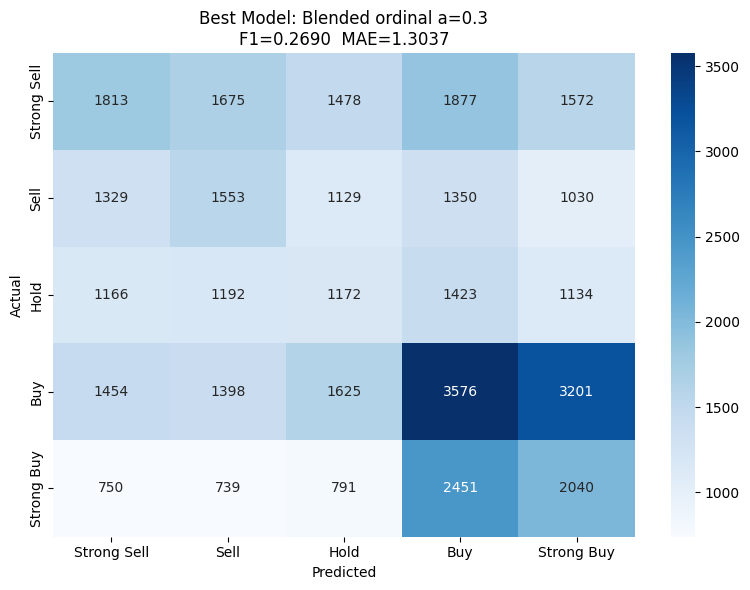

In [47]:
#  Confusion matrix for best model 
best_preds = y_pred_baseline  # default
if best_key == "optuna_purged" and "optuna_purged" in results:
    best_preds = y_pred_optuna
elif best_key == "recency_365d":
    best_preds = y_pred_recency
elif best_key == "recency_730d":
    best_preds = y_pred_recency_730
elif best_key == "boundary_filtered":
    best_preds = y_pred_clean

cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=SIGNAL_LABELS, yticklabels=SIGNAL_LABELS, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Best Model: {results[best_key]['desc']}\nF1={results[best_key]['f1']:.4f}  MAE={results[best_key]['mae']:.4f}")
plt.tight_layout()
plt.show()

In [49]:
cm = confusion_matrix(y_test, y_pred_best)
print("Predicted →")
print(f"{'':>14}", "  ".join(f"{s:>6}" for s in ["SS", "S", "H", "B", "SB"]))
for i, label in enumerate(SIGNAL_LABELS):
    row = "  ".join(f"{cm[i,j]:>6}" for j in range(5))            
    print(f"{label:>14} {row}")

Predicted →
                   SS       S       H       B      SB
   Strong Sell   2688    1207     958    3204     358
          Sell   2031    1138     790    2201     231
          Hold   1779     806     848    2346     308
           Buy   1964    1151    1114    6185     840
    Strong Buy   1139     541     509    3984     598


In [48]:
#  Save results to JSON 
results_path = os.path.join(CACHE_DIR, "09_improvement_results.json")
serializable = {}
for k, v in results.items():
    serializable[k] = {kk: (float(vv) if isinstance(vv, (np.floating, float)) else vv)
                       for kk, vv in v.items()}

with open(results_path, "w") as f:
    json.dump(serializable, f, indent=2)
print(f"Results saved to {results_path}")

Results saved to .\data\09_improvement_results.json


In [51]:
# Save the blended ordinal model for production
model_path = "../src/ml/app/models/xgb_3m_blended.json"
model_best.save_model(model_path)                                       
print(f"Model saved to {model_path}")

Model saved to ../src/ml/app/models/xgb_3m_blended.json
